# 02 — Feature Engineering
## Santander Customer Satisfaction

**Input:** `pickles/train_eda.pkl`, `pickles/test_eda.pkl`  
**Output:** `pickles/train_clean.pkl`, `pickles/test_clean.pkl`

### What we do here (in order):
1. Load data from EDA pickle
2. Step 1 — Remove zero variance features
3. Step 2 — Remove sparse features
4. Step 3 — Remove duplicate columns
5. Step 4 — Fix var3 sentinel value
6. Step 5 — Engineer new features
7. Step 6 — Log transform skewed features
8. Step 7 — Remove low correlation + high inter-correlation features
9. Step 8 — Final feature summary
10. Save clean pickles

---
**Golden Rule:** Every transformation applied to train MUST be applied to test in exactly the same way.

## 1. Imports and Load Data

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import os

sns.set(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 4)

PICKLE_DIR = '../pickles/'
os.makedirs(PICKLE_DIR, exist_ok=True)

# Load from EDA output
train = pd.read_pickle(f'{PICKLE_DIR}train_eda.pkl')
test  = pd.read_pickle(f'{PICKLE_DIR}test_eda.pkl')

print(f'Train loaded: {train.shape}')
print(f'Test loaded : {test.shape}')
print(f'Target distribution: {train["TARGET"].value_counts().to_dict()}')

Train loaded: (76020, 371)
Test loaded : (75818, 370)
Target distribution: {0: 73012, 1: 3008}


## 2. Helper: Feature Tracker

We track how many features we have after each step.  
This is how you show your professor what each step contributes.

In [2]:
# We will log each step here
feature_log = []

def log_step(step_name, train_df):
    """Track feature count after each engineering step."""
    n = len([c for c in train_df.columns if c not in ['ID', 'TARGET']])
    feature_log.append({'Step': step_name, 'Features': n})
    print(f'[{step_name}] Features remaining: {n}')

log_step('START', train)

[START] Features remaining: 369


---
## STEP 1 — Remove Zero Variance Features

**What:** A feature where every single customer has the same value.  
**Why drop:** If everyone has the same value, it cannot help separate satisfied from dissatisfied.  
**Example:** If `ind_var99` = 0 for all 76,000 customers, it tells us nothing.

In [3]:
def remove_zero_variance(train, test):
    """
    Remove features where variance == 0
    (i.e. every row has the exact same value)
    """
    feature_cols = [c for c in train.columns if c not in ['ID', 'TARGET']]
    
    zero_var_cols = [c for c in feature_cols if train[c].var() == 0]
    
    train = train.drop(columns=zero_var_cols)
    test  = test.drop(columns=[c for c in zero_var_cols if c in test.columns])
    
    print(f'  Dropped {len(zero_var_cols)} zero-variance features')
    print(f'  Example dropped: {zero_var_cols[:5]}')
    return train, test

train, test = remove_zero_variance(train, test)
log_step('After Remove Zero Variance', train)

  Dropped 34 zero-variance features
  Example dropped: ['ind_var2_0', 'ind_var2', 'ind_var27_0', 'ind_var28_0', 'ind_var28']
[After Remove Zero Variance] Features remaining: 335


---
## STEP 2 — Remove Sparse Features

**What:** Features where 99%+ of customers have a value of zero.  
**Why drop:** A feature that is 0 for 99% of customers has almost no signal.  
**How we detect:** If the 99th percentile value is 0, then at least 99% of values are zero.

In [4]:
def remove_sparse_features(train, test, threshold=99):
    """
    Remove features where the 99th percentile value is 0.
    This means 99%+ of values are zero — too sparse to be useful.
    threshold: percentile to check (default 99)
    """
    feature_cols = [c for c in train.columns if c not in ['ID', 'TARGET']]
    
    sparse_cols = [c for c in feature_cols 
                   if np.percentile(train[c], threshold) == 0]
    
    train = train.drop(columns=sparse_cols)
    test  = test.drop(columns=[c for c in sparse_cols if c in test.columns])
    
    print(f'  Dropped {len(sparse_cols)} sparse features (99th pct = 0)')
    return train, test

train, test = remove_sparse_features(train, test)
log_step('After Remove Sparse', train)

  Dropped 188 sparse features (99th pct = 0)
[After Remove Sparse] Features remaining: 147


---
## STEP 3 — Remove Duplicate Columns

**What:** Two columns that have identical values for every single customer.  
**Why drop:** They carry exactly the same information — keeping both confuses the model.  
**Note:** Column names are different but values are identical — common in anonymized datasets.

In [5]:
def remove_duplicate_columns(train, test):
    """
    Find columns with identical values and remove duplicates.
    We keep the first occurrence, drop the rest.
    
    How it works:
    - For each pair of columns, check if values match exactly
    - If yes, mark second column for removal
    """
    feature_cols = [c for c in train.columns if c not in ['ID', 'TARGET']]
    
    seen = {}      # stores hash -> first column name
    dup_cols = []  # columns to drop
    
    for col in feature_cols:
        # Create a hashable key from column values
        col_key = tuple(train[col].values)
        if col_key in seen:
            dup_cols.append(col)  # this is a duplicate
        else:
            seen[col_key] = col   # first time seeing this pattern
    
    train = train.drop(columns=dup_cols)
    test  = test.drop(columns=[c for c in dup_cols if c in test.columns])
    
    print(f'  Dropped {len(dup_cols)} duplicate columns')
    return train, test

print('Running duplicate check (may take 1-2 minutes on full data)...')
train, test = remove_duplicate_columns(train, test)
log_step('After Remove Duplicates', train)

Running duplicate check (may take 1-2 minutes on full data)...
  Dropped 6 duplicate columns
[After Remove Duplicates] Features remaining: 141


---
## STEP 4 — Fix var3 Sentinel Value

**What:** `var3` contains `-999999` which is a coded missing value (not a real number).  
**Why fix:** If we leave it, the model thinks some customers have an account balance of -999999, which is nonsense.  
**Fix:** Replace with the most common value (mode) — the safest assumption.

In [6]:
def fix_var3(train, test):
    """
    Replace -999999 sentinel value in var3 with the mode (most common value).
    
    Important: We compute the mode from TRAIN only,
    then apply it to both train and test.
    Never compute statistics from test data.
    """
    if 'var3' not in train.columns:
        print('  var3 not found — may have been dropped as duplicate/sparse')
        return train, test
    
    # Count how many -999999 values exist
    n_sentinel_train = (train['var3'] == -999999).sum()
    n_sentinel_test  = (test['var3']  == -999999).sum() if 'var3' in test.columns else 0
    
    # Compute mode from train (excluding sentinel)
    mode_val = train.loc[train['var3'] != -999999, 'var3'].mode()[0]
    
    # Replace in both
    train['var3'] = train['var3'].replace(-999999, mode_val)
    if 'var3' in test.columns:
        test['var3'] = test['var3'].replace(-999999, mode_val)
    
    print(f'  var3: replaced {n_sentinel_train} sentinel values in train')
    print(f'  var3: replaced {n_sentinel_test} sentinel values in test')
    print(f'  Replacement value (mode): {mode_val}')
    return train, test

train, test = fix_var3(train, test)
log_step('After Fix var3', train)

  var3: replaced 116 sentinel values in train
  var3: replaced 120 sentinel values in test
  Replacement value (mode): 2
[After Fix var3] Features remaining: 141


---
## STEP 5 — Engineer New Features

This is the most important step. We create new features that the model cannot figure out on its own.

### Features we create:
| Feature | What it captures | Why useful |
|---|---|---|
| `num_zeros` | How many zero values per customer | Dissatisfied customers may use fewer products |
| `num_zeros_saldo` | Zeros in balance columns | Zero balance = inactive account |
| `num_zeros_imp` | Zeros in amount columns | Zero transactions = low engagement |
| `num_zeros_num` | Zeros in count columns | Low transaction count |
| `num_zeros_ind` | Zeros in indicator columns | No product indicators |
| `var15_below_23` | Is customer under 23? | Young customers behave differently |
| `var15_bin` | Age group (5 bins) | Age group patterns |
| `log_var38` | Log of var38 | Reduces extreme skew in account value |

In [7]:
def add_zero_count_features(train, test):
    """
    Add features counting zeros per row — overall and per column group.
    
    Intuition: Dissatisfied customers tend to have more zero-value features
    because they use fewer bank products/services.
    """
    feature_cols = [c for c in train.columns if c not in ['ID', 'TARGET']]
    
    # Define column groups
    groups = {
        'saldo' : [c for c in feature_cols if 'saldo' in c],
        'imp'   : [c for c in feature_cols if 'imp'   in c],
        'num'   : [c for c in feature_cols if c.startswith('num')],
        'ind'   : [c for c in feature_cols if c.startswith('ind')],
    }
    
    for df in [train, test]:
        # Overall zero count
        df['num_zeros'] = (df[feature_cols] == 0).sum(axis=1)
        
        # Group-level zero counts
        for group_name, cols in groups.items():
            if cols:  # only if group has columns
                df[f'num_zeros_{group_name}'] = (df[cols] == 0).sum(axis=1)
    
    new_features = ['num_zeros'] + [f'num_zeros_{g}' for g in groups.keys()]
    print(f'  Added zero count features: {new_features}')
    return train, test


def add_var15_features(train, test):
    """
    Engineer features from var15 (customer age).
    
    - var15_below_23: Binary flag — customers under 23 have very different behaviour
    - var15_bin: Age grouped into 5 buckets
    
    Note: We compute bin edges from TRAIN only, then apply to test.
    """
    if 'var15' not in train.columns:
        print('  var15 not found — skipping')
        return train, test
    
    for df in [train, test]:
        # Binary: is customer younger than 23?
        df['var15_below_23'] = (df['var15'] < 23).astype(int)
    
    # Bin into 5 age groups — learn bins from train only
    _, bin_edges = pd.cut(train['var15'], bins=5, retbins=True)
    
    train['var15_bin'] = pd.cut(train['var15'], bins=bin_edges, labels=False, 
                                 include_lowest=True)
    test['var15_bin']  = pd.cut(test['var15'],  bins=bin_edges, labels=False,
                                 include_lowest=True)
    
    # Fill any NaN bins in test (edge case where test has values outside train range)
    test['var15_bin'] = test['var15_bin'].fillna(0).astype(int)
    train['var15_bin'] = train['var15_bin'].fillna(0).astype(int)
    
    print(f'  Added var15_below_23 and var15_bin (5 age groups)')
    print(f'  Age bins used: {[round(e,1) for e in bin_edges]}')
    return train, test


def add_log_var38(train, test):
    """
    Add log-transformed var38.
    var38 is likely account value — highly right-skewed.
    Log transform brings it closer to normal distribution,
    which helps models like Logistic Regression.
    
    log1p(x) = log(x+1) — safe for zero values.
    """
    if 'var38' not in train.columns:
        print('  var38 not found — skipping')
        return train, test
    
    for df in [train, test]:
        df['log_var38'] = np.log1p(df['var38'].clip(lower=0))
    
    print(f'  Added log_var38')
    print(f'  var38 skewness before: {train["var38"].skew():.2f}')
    print(f'  log_var38 skewness after: {train["log_var38"].skew():.2f}')
    return train, test


# Run all feature engineering
print('=== Adding Engineered Features ===')
train, test = add_zero_count_features(train, test)
train, test = add_var15_features(train, test)
train, test = add_log_var38(train, test)

log_step('After Feature Engineering', train)

=== Adding Engineered Features ===
  Added zero count features: ['num_zeros', 'num_zeros_saldo', 'num_zeros_imp', 'num_zeros_num', 'num_zeros_ind']
  Added var15_below_23 and var15_bin (5 age groups)
  Age bins used: [4.9, 25.0, 45.0, 65.0, 85.0, 105.0]
  Added log_var38
  var38 skewness before: 51.27
  log_var38 skewness after: 0.38
[After Feature Engineering] Features remaining: 149


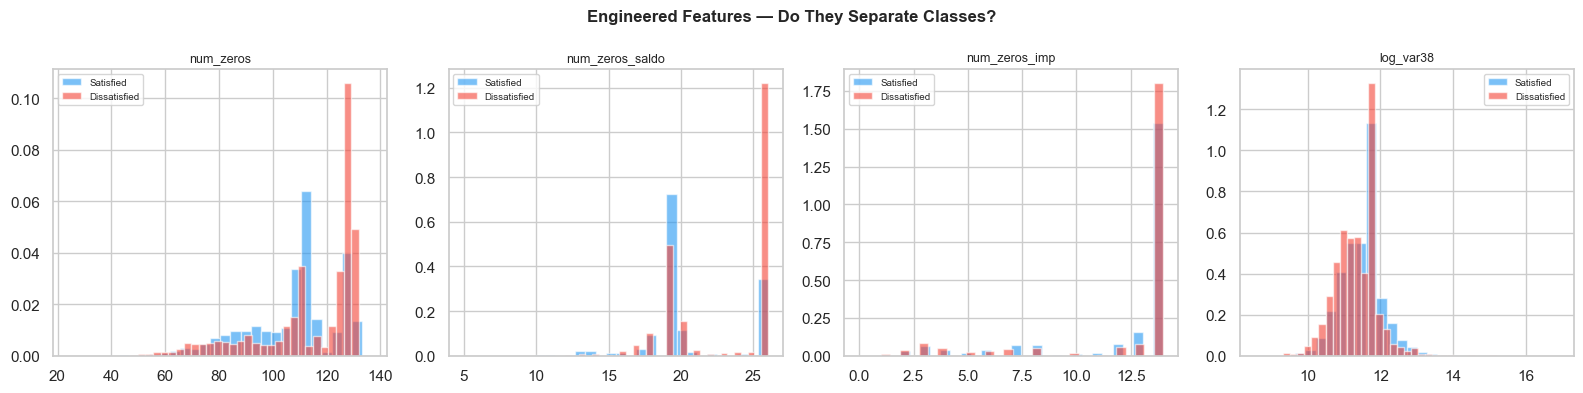

If distributions differ between classes → feature is useful!


In [8]:
# Visualize: do our new features separate classes?
new_feats = ['num_zeros', 'num_zeros_saldo', 'num_zeros_imp', 'log_var38']
new_feats = [f for f in new_feats if f in train.columns]

fig, axes = plt.subplots(1, len(new_feats), figsize=(16, 4))

for i, col in enumerate(new_feats):
    for target_val, color, label in [(0, '#2196F3', 'Satisfied'), 
                                      (1, '#F44336', 'Dissatisfied')]:
        subset = train[train['TARGET'] == target_val][col]
        axes[i].hist(subset, bins=30, alpha=0.6, color=color, 
                     label=label, density=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)

plt.suptitle('Engineered Features — Do They Separate Classes?', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PICKLE_DIR}engineered_features.png', dpi=120, bbox_inches='tight')
plt.show()
print('If distributions differ between classes → feature is useful!')

---
## STEP 6 — Log Transform Skewed Features

**What:** `saldo` (balance) and `imp` (amount) columns are highly right-skewed.  
**Problem:** A few customers have huge balances. This confuses the model — it over-focuses on extreme values.  
**Fix:** Apply `log1p` transform to compress the scale.  

**Rule:** Only apply log to columns where all values >= 0 (log of negative = undefined).

In [9]:
def apply_log_transform(train, test, skew_threshold=1.5):
    """
    Apply log1p transformation to highly skewed saldo and imp features.
    
    skew_threshold: only transform if skewness > this value
    Only applied to columns where ALL values >= 0
    """
    feature_cols = [c for c in train.columns if c not in ['ID', 'TARGET']]
    
    # Only saldo and imp groups — these are financial amounts
    candidates = [c for c in feature_cols 
                  if ('saldo' in c or 'imp' in c or c == 'var38')
                  and 'log_' not in c]  # don't transform already-transformed cols
    
    transformed = []
    for col in candidates:
        # Only transform if all values are non-negative
        if train[col].min() >= 0:
            skewness = train[col].skew()
            if abs(skewness) > skew_threshold:
                for df in [train, test]:
                    df[col] = np.log1p(df[col])
                transformed.append(col)
    
    print(f'  Log transformed {len(transformed)} skewed features')
    print(f'  Columns transformed: {transformed[:10]}'
          f'{" ..." if len(transformed) > 10 else ""}')
    return train, test

train, test = apply_log_transform(train, test)
log_step('After Log Transform', train)

  Log transformed 31 skewed features
  Columns transformed: ['imp_ent_var16_ult1', 'imp_op_var39_comer_ult1', 'imp_op_var39_comer_ult3', 'imp_op_var41_comer_ult1', 'imp_op_var41_comer_ult3', 'imp_op_var41_efect_ult1', 'imp_op_var41_efect_ult3', 'imp_op_var41_ult1', 'imp_op_var39_efect_ult1', 'imp_op_var39_efect_ult3'] ...
[After Log Transform] Features remaining: 149


---
## STEP 7 — Remove Low Correlation + Highly Correlated Features

Two types of features to remove:

**Type A — Low correlation with TARGET:**  
If a feature has near-zero correlation with what we're predicting, it adds noise.

**Type B — High correlation with another feature:**  
If two features are 95%+ correlated with each other, they carry the same information.  
Keep the one more correlated with TARGET, drop the other.

In [10]:
def remove_correlated_features(train, test, 
                                target_threshold=1e-3, 
                                within_threshold=0.95):
    """
    Remove features that:
    A) Have very low correlation with TARGET (< target_threshold)
    B) Are highly correlated with another feature (> within_threshold)
       — in this case, keep the one more correlated with TARGET
    
    target_threshold : minimum absolute correlation with TARGET to keep
    within_threshold : if two features correlate above this, drop one
    """
    feature_cols = [c for c in train.columns if c not in ['ID', 'TARGET']]
    
    # --- Part A: Remove low correlation with target ---
    target_corr = train[feature_cols + ['TARGET']].corr()['TARGET'].drop('TARGET')
    low_corr_cols = target_corr[target_corr.abs() < target_threshold].index.tolist()
    
    train = train.drop(columns=low_corr_cols)
    test  = test.drop(columns=[c for c in low_corr_cols if c in test.columns])
    print(f'  Dropped {len(low_corr_cols)} low-correlation-with-target features')
    
    # Update feature_cols after dropping
    feature_cols = [c for c in train.columns if c not in ['ID', 'TARGET']]
    
    # --- Part B: Remove highly correlated feature pairs ---
    # Recompute target correlations for remaining features
    target_corr = train[feature_cols + ['TARGET']].corr()['TARGET'].drop('TARGET')
    
    # Compute feature-feature correlation matrix
    corr_matrix = train[feature_cols].corr().abs()
    
    to_drop = set()
    for i in range(len(feature_cols)):
        for j in range(i + 1, len(feature_cols)):
            col_i = feature_cols[i]
            col_j = feature_cols[j]
            
            if col_i in to_drop or col_j in to_drop:
                continue
            
            if corr_matrix.loc[col_i, col_j] > within_threshold:
                # Drop the one less correlated with TARGET
                if abs(target_corr[col_i]) >= abs(target_corr[col_j]):
                    to_drop.add(col_j)
                else:
                    to_drop.add(col_i)
    
    to_drop = list(to_drop)
    train = train.drop(columns=to_drop)
    test  = test.drop(columns=[c for c in to_drop if c in test.columns])
    print(f'  Dropped {len(to_drop)} highly-inter-correlated features')
    
    return train, test

print('Running correlation-based feature removal...')
print('(May take 2-3 minutes on full data)')
train, test = remove_correlated_features(train, test)
log_step('After Correlation Removal', train)

Running correlation-based feature removal...
(May take 2-3 minutes on full data)
  Dropped 2 low-correlation-with-target features
  Dropped 52 highly-inter-correlated features
[After Correlation Removal] Features remaining: 95


---
## STEP 8 — Final Feature Summary

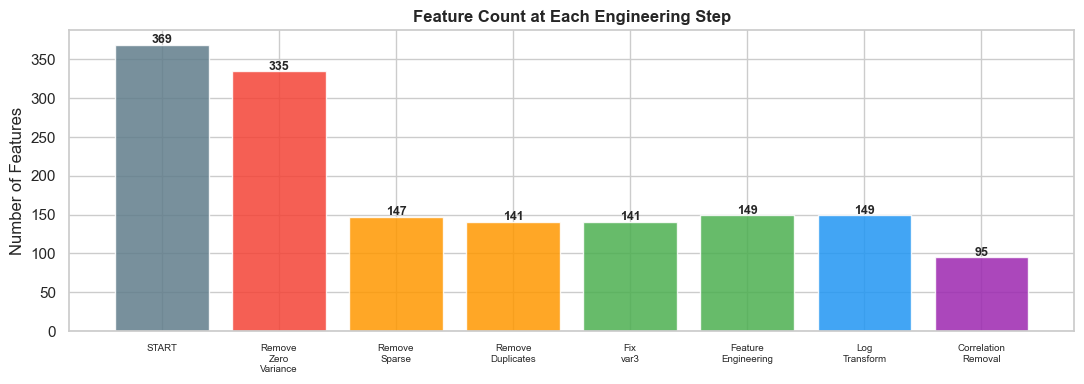

In [11]:
# Full feature journey visualization
fig, ax = plt.subplots(figsize=(11, 4))

steps  = [d['Step'] for d in feature_log]
counts = [d['Features'] for d in feature_log]

bars = ax.bar(range(len(steps)), counts, 
              color=['#607D8B','#F44336','#FF9800','#FF9800',
                     '#4CAF50','#4CAF50','#2196F3','#9C27B0'][:len(steps)],
              alpha=0.85, edgecolor='white')

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(count), ha='center', fontweight='bold', fontsize=9)

ax.set_xticks(range(len(steps)))
ax.set_xticklabels([s.replace('After ', '').replace(' ', '\n') 
                    for s in steps], fontsize=7)
ax.set_ylabel('Number of Features')
ax.set_title('Feature Count at Each Engineering Step', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PICKLE_DIR}feature_journey.png', dpi=120, bbox_inches='tight')
plt.show()

In [12]:
# Final summary
feature_cols_final = [c for c in train.columns if c not in ['ID', 'TARGET']]

print('=' * 55)
print('FEATURE ENGINEERING SUMMARY')
print('=' * 55)
print(f'Started with : 370 features')
print(f'Ended with   : {len(feature_cols_final)} features')
print()
print('Journey:')
for d in feature_log:
    print(f'  {d["Step"]:<40} → {d["Features"]} features')
print()
print('Final train shape:', train.shape)
print('Final test shape :', test.shape)
print()
print('Engineered features added:')
eng = [c for c in feature_cols_final 
       if c.startswith(('num_zeros', 'var15_', 'log_'))]
for c in eng:
    print(f'  + {c}')
print()
print('Train and test have same columns:', 
      set(feature_cols_final) == set([c for c in test.columns if c not in ['ID']]))
print('=' * 55)

FEATURE ENGINEERING SUMMARY
Started with : 370 features
Ended with   : 95 features

Journey:
  START                                    → 369 features
  After Remove Zero Variance               → 335 features
  After Remove Sparse                      → 147 features
  After Remove Duplicates                  → 141 features
  After Fix var3                           → 141 features
  After Feature Engineering                → 149 features
  After Log Transform                      → 149 features
  After Correlation Removal                → 95 features

Final train shape: (76020, 97)
Final test shape : (75818, 96)

Engineered features added:
  + num_zeros
  + num_zeros_saldo
  + num_zeros_imp
  + num_zeros_ind
  + var15_below_23
  + var15_bin

Train and test have same columns: True


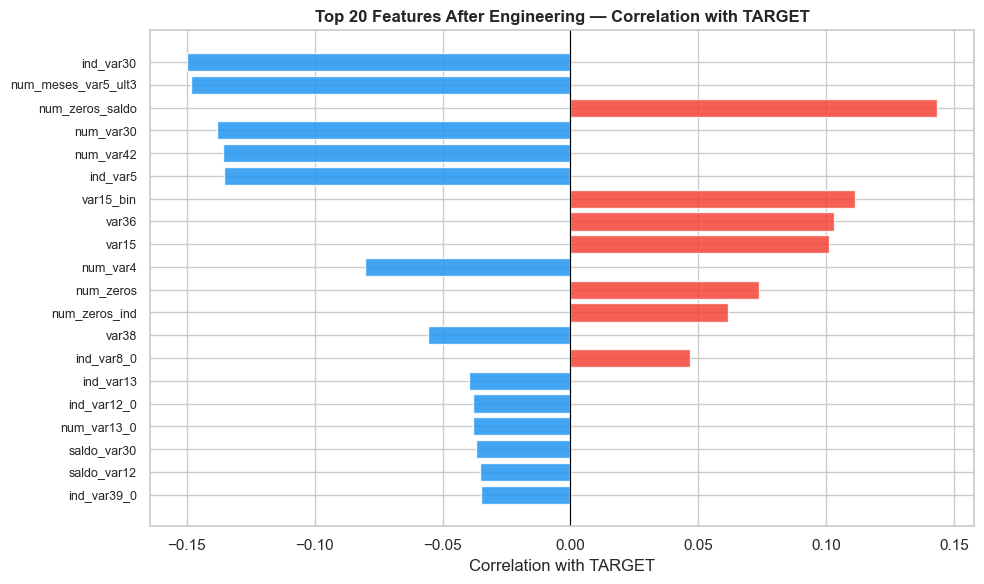

In [13]:
# Final correlation check — top 20 features in clean dataset
final_corr = (train[feature_cols_final + ['TARGET']]
              .corr()['TARGET']
              .drop('TARGET')
              .sort_values(key=abs, ascending=False)
              .head(20))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#F44336' if v > 0 else '#2196F3' for v in final_corr.values]
ax.barh(range(len(final_corr)), final_corr.values, 
        color=colors, alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(final_corr)))
ax.set_yticklabels(final_corr.index, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlation with TARGET')
ax.set_title('Top 20 Features After Engineering — Correlation with TARGET',
             fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{PICKLE_DIR}final_correlations.png', dpi=120, bbox_inches='tight')
plt.show()

---
## STEP 9 — Verify Before Saving

Always do these sanity checks before saving.  
If any check fails — do not proceed to modeling.

In [14]:
print('=== SANITY CHECKS ===')
checks_passed = True

# Check 1: No missing values
train_nulls = train.isnull().sum().sum()
test_nulls  = test.isnull().sum().sum()
status = '✅' if train_nulls == 0 and test_nulls == 0 else '❌'
print(f'{status} Missing values — train: {train_nulls}, test: {test_nulls}')
if train_nulls > 0 or test_nulls > 0:
    checks_passed = False

# Check 2: Same features in train and test
train_feats = set([c for c in train.columns if c not in ['ID','TARGET']])
test_feats  = set([c for c in test.columns  if c not in ['ID']])
same_cols = train_feats == test_feats
status = '✅' if same_cols else '❌'
print(f'{status} Same features in train and test: {same_cols}')
if not same_cols:
    print(f'   In train not test: {train_feats - test_feats}')
    print(f'   In test not train: {test_feats - train_feats}')
    checks_passed = False

# Check 3: Target still in train, not in test
status = '✅' if 'TARGET' in train.columns and 'TARGET' not in test.columns else '❌'
print(f'{status} TARGET in train only')

# Check 4: No zero variance in final set
zero_var_remaining = [c for c in train_feats if train[c].var() == 0]
status = '✅' if len(zero_var_remaining) == 0 else '⚠️'
print(f'{status} Zero variance features remaining: {len(zero_var_remaining)}')

# Check 5: Feature count is reasonable
n_features = len(train_feats)
status = '✅' if 50 <= n_features <= 300 else '⚠️'
print(f'{status} Final feature count: {n_features} (expected 100-200)')

# Check 6: No -999999 in var3
if 'var3' in train.columns:
    has_sentinel = (train['var3'] == -999999).any()
    status = '✅' if not has_sentinel else '❌'
    print(f'{status} var3 sentinel value fixed: {not has_sentinel}')

print()
if checks_passed:
    print('✅ All checks passed — safe to save and proceed to modeling')
else:
    print('❌ Some checks failed — review above before proceeding')

=== SANITY CHECKS ===
✅ Missing values — train: 0, test: 0
✅ Same features in train and test: True
✅ TARGET in train only
✅ Zero variance features remaining: 0
✅ Final feature count: 95 (expected 100-200)
✅ var3 sentinel value fixed: True

✅ All checks passed — safe to save and proceed to modeling


---
## STEP 10 — Save Clean Pickles

In [15]:
# Save final clean datasets
train.to_pickle(f'{PICKLE_DIR}train_clean.pkl')
test.to_pickle(f'{PICKLE_DIR}test_clean.pkl')

print(f'✅ Saved: {PICKLE_DIR}train_clean.pkl  →  {train.shape}')
print(f'✅ Saved: {PICKLE_DIR}test_clean.pkl   →  {test.shape}')
print()
print('Next steps:')
print('  Local → Upload pickles/train_clean.pkl + test_clean.pkl to Google Drive')
print('  Colab → Run 03_XGBoost.ipynb')

✅ Saved: ../pickles/train_clean.pkl  →  (76020, 97)
✅ Saved: ../pickles/test_clean.pkl   →  (75818, 96)

Next steps:
  Local → Upload pickles/train_clean.pkl + test_clean.pkl to Google Drive
  Colab → Run 03_XGBoost.ipynb
